In [866]:
import numpy as np
import pandas as pd
from utils.utils import discretizar, conservar_filas_con_n_no_nulos, get_filas_con_n_nulos, eliminar_duplicados, obtener_palabras_en_campo_que_contienen_substr
from matplotlib import pyplot as plt

from utils.load_data import load_excelfile, load_databases
from utils.estadisticas import mostrar_frecuencias, mostrar_unicos, mostrar_rango, mostrar_valores_nulos, \
                               mostrar_duplicados, graficar_segun_fecha

from utils.IAE import filtrar_IAES_por_fecha_registro, agregar_tipo_prestador_IAE, guardar_prestadores, acondicionar_atributo_metodo, \
                      agregar_categoria_metodo, acondicionar_IAE_PREVIO, calcular_y_agregar_campo_edad, acondicionar_campo_DECISION, \
                      agregar_campo_DECISION, agregar_si_intentos_en_CDE, agregar_datos_CDE_en_IAE, agregar_dias_IAE_a_muerte  
from utils.CDE import conciden_fechas_nacimiento_digitadas_y_calculadas, \
                      agregar_atributo_CAT_SUI, argegar_atributo_CAT_MCEXSUI
from utils.agregado import agregar_base_intentos, agregar_campo, personas_con_IAE_no_presentes_en_CDE, personas_en_CDE_sin_IAE, \
                           agregar_IAE_PREVIO_corregido, personas_con_IAE_no_presentes_en_CNV, personas_en_CNV_sin_IAE, \
                        personas_con_IAE_no_presentes_en_RUCAF, personas_en_RUCAF_sin_IAE, personas_con_IAE_no_presentes_en_SHARPS, \
                        personas_en_SHARPS_sin_IAE, personas_con_IAE_no_presentes_en_SIV, personas_en_SIV_sin_IAE


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [867]:
# configuración
dataset = 1 # 1 primera entrega, 2 segunda entrega

campo_decision = 'DECISION' if dataset==2 else 'DECISIÓN'
campo_nacimiento = 'FECHA NACIMIENTO' if dataset==2 else 'NACIMIENTO'

In [855]:
archivo_primera_entrega = "/home/carbajal/Documents/SaludMental/Datos recibidos en primer instancia.xlsx"
archivo_segunda_entrega ='/home/carbajal/Documents/SaludMental/2da entrega 20260210/Planilla completa.xlsx'
archivo = archivo_primera_entrega if dataset==1 else archivo_segunda_entrega

In [856]:
# Levantar las bases. La segunda entrega tiene la base de egresos hospitalarios que no tiene la primera
if dataset ==1:
       df_IAE, df_IAE_CDE, df_IAE_CNV, df_IAE_RUCAF, df_IAE_SHARPS, df_IAE_SIV = load_databases(archivo, dataset)
elif dataset==2:
       df_IAE, df_IAE_CDE, df_IAE_CNV, df_IAE_RUCAF, df_IAE_SHARPS, df_IAE_SIV, df_IAE_EH = load_databases(archivo, dataset)


['IAE', 'IAE_CDE', 'IAE_CNV', 'IAE_RUCAF', 'IAE_SHARPS', 'IAE_SIV', 'Hoja1']


In [857]:
#df_julio = df_IAE[(df_IAE['REGISTRO'] >= '2023-07-01') & (df_IAE['REGISTRO'] < '2023-08-01')]
df_julio = filtrar_IAES_por_fecha_registro(df_IAE, '2023-07-01', '2023-08-01')
df_julio

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
7,003f0194d6bd3f359f2097b177e8de7778c77706c6cb5f...,Masculino,1996-04-01,ASSE - BELLA UNION,HOSPITAL BELLA UNION,2023-07-11,Otros,SI,2023-06-30,27.0,NO CUMPLE PROTOCOLO
19,007a5dd46377a17f971e0f1f38a46489679b3346323413...,Masculino,1996-07-01,ASSE - ROCHA,HOSPITAL DE ROCHA,2023-07-20,Lesiones autoinfligidas,NO,2023-07-19,26.0,NO CUMPLE PROTOCOLO
53,0124230c21624a07c5f200529a47df92671c7bff4443f2...,Masculino,2005-12-01,CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORI...,NaN,2023-07-07,Otros,NO,2023-07-07,17.0,RESUELTO
56,0131dfab7958fc381e6c1ccdc524c6b48f444436baefbb...,Femenino,1992-04-01,CRAME,NaN,2023-07-24,Ingesta de Medicamentos,NO,2023-07-24,31.0,RESUELTO
72,019d3bd85bb57a17a8ba5d38c13f2b208b9f54fe643aef...,Masculino,2007-12-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,NaN,2023-07-24,Ahorcamiento o asfixia,NO,2023-07-24,15.0,RESUELTO
...,...,...,...,...,...,...,...,...,...,...,...
10279,fc81373b3840abac1e888eec2541780af6cde05655f25e...,Femenino,1984-05-01,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,NaN,2023-07-14,Ingesta de Medicamentos,SI,2023-07-14,39.0,RESUELTO
10321,fd64b4637915827551985995fed78a69a7863fb0a93177...,Femenino,2012-10-01,MEDICA URUGUAYA MUCAM,NaN,2023-07-26,Lesiones autoinfligidas,NO,2023-07-22,10.0,RESUELTO
10400,ff5a3a7e073e649548692f3b675d0853ba4c759e9ad9e8...,Femenino,1992-01-01,ASSE - MALDONADO,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2023-07-03,Otros,SI,2023-06-30,31.0,NO CUMPLE PROTOCOLO
10416,ffbacea7e7a83c5202df1c51e4a650869e3194d4ad423e...,Masculino,1997-03-01,ASSE - MALDONADO,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2023-07-31,Ingesta de Medicamentos,SI,2023-07-28,26.0,NO CUMPLE PROTOCOLO


# Análisis de la base de IAE_CDE  (Certificados de defunción)

In [501]:
df_IAE_CDE.shape  # primera versión tenía 270 filas, ahora 4678

(270, 9)

In [502]:
#df_IAE_CDE = df_IAE_CDE.dropna(thresh=3) # si tiene al menos tres valores no nulos me quedo con las filas
df_IAE_CDE = eliminar_filas_con_n_nulos(df_IAE_CDE, n=3)


La base tenía 270 filas. Luego de eliminar las filas con al menos 3 campos nulos quedaron 269 filas


In [503]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269 entries, 0 to 268
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           269 non-null    object        
 1   fecha_defuncion                  269 non-null    datetime64[ns]
 2   causa_basica_muerte_valor        252 non-null    object        
 3   causa_basica_muerte_descripcion  252 non-null    object        
 4   lugar_ocurrencia                 269 non-null    object        
 5   lugar_ocurrencia_detalle         11 non-null     object        
 6   departamento_ocurrencia          269 non-null    object        
 7   edad_fallecimiento_calculada     269 non-null    float64       
 8   edad_fallecimiento_digitada      268 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 21.0+ KB


In [504]:
#np.sum(df_IAE_CDE.duplicated()) # no hay duplicados
mostrar_duplicados(df_IAE_CDE)

La base tiene 0 filas duplicadas


In [505]:
if dataset==2: # la variable etnia está solo en la segunda entrega
    df_IAE_CDE['etnia'].value_counts()

In [506]:
if dataset==2: # la variable etnia está solo en la segunda entrega
    df_IAE_CDE['institucion_fallecio'].value_counts()

In [507]:
#df_IAE_CDE['motivo_externo'].value_counts()

In [508]:
#len(df_IAE['CEDULA'].unique())
mostrar_unicos(df_IAE,'CEDULA')

CEDULA tiene 8828 valores únicos.
['0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2'
 '00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22'
 '00133099d10f0d6d56bd2f58267ff271fd097b1682638fc7405967ed68fbeff5' ...
 'fff70f241b7a38806c1580fb5d8077c97d84bc6256b0aefb96ce7f4d04b484c2'
 'fff9a612ad60860b9c3be2ca6b24e6d338b2a8f62b11f7602b4f14707c32dfd5' 10427]


In [509]:
conciden_fechas_nacimiento_digitadas_y_calculadas(df_IAE_CDE)

Las fechas de nacimineto digitadas y calculadas coinciden en 268 de 269 casos


In [510]:
df_IAE_CDE[df_IAE_CDE['edad_fallecimiento_calculada']==0]

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada


In [511]:
#df_IAE_CDE['lugar_ocurrencia'].value_counts()
mostrar_frecuencias(df_IAE_CDE,'lugar_ocurrencia')

lugar_ocurrencia
CENTRO ASISTENCIAL     120
DOMICILIO              117
OTRO                    17
VÍA PÚBLICA              7
CASA DE SALUD/ASILO      5
CÁRCEL                   3
Name: count, dtype: int64


In [512]:
#np.sum(df_IAE_CDE['cedula'].isnull()) # no hay campos vacíos en las cédulas
mostrar_valores_nulos(df_IAE_CDE,'cedula')

cedula tiene 0 valores nulos


In [513]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269 entries, 0 to 268
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           269 non-null    object        
 1   fecha_defuncion                  269 non-null    datetime64[ns]
 2   causa_basica_muerte_valor        252 non-null    object        
 3   causa_basica_muerte_descripcion  252 non-null    object        
 4   lugar_ocurrencia                 269 non-null    object        
 5   lugar_ocurrencia_detalle         11 non-null     object        
 6   departamento_ocurrencia          269 non-null    object        
 7   edad_fallecimiento_calculada     269 non-null    float64       
 8   edad_fallecimiento_digitada      268 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 21.0+ KB


In [514]:
#df_IAE_CDE['causa_basica_muerte_valor'].unique()
mostrar_unicos(df_IAE_CDE,'causa_basica_muerte_valor')
mostrar_unicos(df_IAE_CDE,'lugar_ocurrencia')

causa_basica_muerte_valor tiene 111 valores únicos.
['R961' 'V445' 'Y218' 'X708' 'X700' 'R99' 'B209' 'X649' 'J690' 'B378'
 'X701' 'X740' 'J189' 'X640' nan 'J440' 'C349' 'X610' 'I330' 'I639' 'I500'
 'C800' 'I490' 'L899' 'J90' 'X760' 'I609' 'I219' 'I608' 'C169' 'M359'
 'J841' 'C61' 'G122' 'X709' 'X618' 'G931' 'X780' 'J459' 'V892' 'K566'
 'F03' 'D65' 'M628' 'K920' 'D432' 'I469' 'J988' 'N189' 'C809' 'X714'
 'X704' 'C189' 'Y833' 'X619' 'C64' 'G310' 'R579' 'I269' 'X769' 'C450'
 'C509' 'W100' 'I509' 'I619' 'C220' 'J22' 'X800' 'I679' 'I620' 'X784'
 'X954' 'X000' 'N19' 'W748' 'J449' 'W790' 'G419' 'X699' 'I517' 'X718'
 'Y209' 'C859' 'R688' 'C710' 'E142' 'I10' 'I249' 'C55' 'I259' 'C259'
 'N390' 'R64' 'X764' 'J182' 'C182' 'I350' 'X849' 'Y249' 'I743' 'E145'
 'L089' 'R572' 'W789' 'G409' 'X689' 'X840' 'X809' 'X749' 'E149' 'X479']
lugar_ocurrencia tiene 6 valores únicos.
['DOMICILIO' 'VÍA PÚBLICA' 'CENTRO ASISTENCIAL' 'OTRO' 'CÁRCEL'
 'CASA DE SALUD/ASILO']


In [515]:
#df_IAE_CDE['departamento_ocurrencia'].value_counts()
mostrar_frecuencias(df_IAE_CDE,'departamento_ocurrencia')

departamento_ocurrencia
MO    113
CA     37
MA     24
PA     15
LA     11
RO      9
SO      7
SJ      7
AR      7
CO      7
DU      6
RV      6
RN      6
TT      5
SA      3
FS      3
TA      2
FD      1
Name: count, dtype: int64


In [516]:
edades_digitadas = df_IAE_CDE["edad_fallecimiento_digitada"]
#print(edades_digitadas)
#print(len(edades_digitadas), edades_digitadas.min(), edades_digitadas.max())
mostrar_rango(df_IAE_CDE,"edad_fallecimiento_digitada")
#print('Valores nulos:',np.sum(edades_digitadas.isnull()))
mostrar_valores_nulos(df_IAE_CDE,"edad_fallecimiento_digitada")
#edades.value_counts()

El rango del atributo edad_fallecimiento_digitada es [14.0, 95.0]
edad_fallecimiento_digitada tiene 1 valores nulos


In [517]:
edades_calculadas = df_IAE_CDE["edad_fallecimiento_calculada"]
#print(edades_calculadas)
mostrar_rango(df_IAE_CDE,"edad_fallecimiento_calculada")

mostrar_valores_nulos(df_IAE_CDE,"edad_fallecimiento_calculada")

#print(np.sum(edades_calculadas==edades_digitadas))
conciden_fechas_nacimiento_digitadas_y_calculadas(df_IAE_CDE)

El rango del atributo edad_fallecimiento_calculada es [14.0, 95.0]
edad_fallecimiento_calculada tiene 0 valores nulos
Las fechas de nacimineto digitadas y calculadas coinciden en 268 de 269 casos


In [518]:
# algunos valores de CIE10 sacados de wikipedia, por ahora no se usan
# en esta base hay mas (R99, J189, E149, etc)


In [519]:
df_IAE_CDE = agregar_atributo_CAT_SUI(df_IAE_CDE)
df_IAE_CDE = argegar_atributo_CAT_MCEXSUI(df_IAE_CDE)

Hay 99 filas de 269 en la categoría CAT_SUI_
Hay 14 filas de 269 en la categoría CAT_MCEXSUI_


In [520]:
#df_IAE_CDE['CAT_MCEXSUI_'] = df_IAE_CDE['causa_basica_muerte_valor'].apply( lambda x : 1 if str(x)[:3] in CAT_MCEXSUI else 0) 

In [521]:
#df_IAE_CDE['causa_basica_muerte_valor'].value_counts()
mostrar_frecuencias(df_IAE_CDE, 'causa_basica_muerte_valor')

causa_basica_muerte_valor
X700    48
R99     17
R961    13
X740    10
J189     6
        ..
X840     1
X809     1
X749     1
E149     1
X479     1
Name: count, Length: 110, dtype: int64


In [522]:
#len(df_IAE_CDE['causa_basica_muerte_valor'].unique())  #En el CIE10 hay 1170 categorías, 
#En el CIE10 hay 1170 categorías
# En la primera entrega se usan acá se usan 110 + nan.  
# En la segunda entrega se usan 38
mostrar_unicos(df_IAE_CDE, 'causa_basica_muerte_valor')

causa_basica_muerte_valor tiene 111 valores únicos.
['R961' 'V445' 'Y218' 'X708' 'X700' 'R99' 'B209' 'X649' 'J690' 'B378'
 'X701' 'X740' 'J189' 'X640' nan 'J440' 'C349' 'X610' 'I330' 'I639' 'I500'
 'C800' 'I490' 'L899' 'J90' 'X760' 'I609' 'I219' 'I608' 'C169' 'M359'
 'J841' 'C61' 'G122' 'X709' 'X618' 'G931' 'X780' 'J459' 'V892' 'K566'
 'F03' 'D65' 'M628' 'K920' 'D432' 'I469' 'J988' 'N189' 'C809' 'X714'
 'X704' 'C189' 'Y833' 'X619' 'C64' 'G310' 'R579' 'I269' 'X769' 'C450'
 'C509' 'W100' 'I509' 'I619' 'C220' 'J22' 'X800' 'I679' 'I620' 'X784'
 'X954' 'X000' 'N19' 'W748' 'J449' 'W790' 'G419' 'X699' 'I517' 'X718'
 'Y209' 'C859' 'R688' 'C710' 'E142' 'I10' 'I249' 'C55' 'I259' 'C259'
 'N390' 'R64' 'X764' 'J182' 'C182' 'I350' 'X849' 'Y249' 'I743' 'E145'
 'L089' 'R572' 'W789' 'G409' 'X689' 'X840' 'X809' 'X749' 'E149' 'X479']


In [523]:
## La base de defunciones no dice el prestador donde se produjo el deceso

In [524]:


# Agrupar edades de a 5 
df_IAE_CDE = discretizar(df_IAE_CDE, "edad_fallecimiento_calculada", "grupo edades_", 5)

# Análisis de la base de IAE  

In [525]:
df_IAE.shape   # 10428 intentos

(10428, 11)

In [526]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10428 entries, 0 to 10427
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CEDULA                    10428 non-null  object        
 1   PERSONA                   10427 non-null  object        
 2   NACIMIENTO                10426 non-null  datetime64[ns]
 3   PRESTADOR RECODIFICADO    10424 non-null  object        
 4   ESTABLECIMIENTO REGISTRO  7502 non-null   object        
 5   REGISTRO                  10427 non-null  datetime64[ns]
 6   METODO                    10427 non-null  object        
 7   IAE PREVIO                10427 non-null  object        
 8   FECHA IAE                 10427 non-null  datetime64[ns]
 9   EDAD                      10426 non-null  float64       
 10  DECISIÓN                  10427 non-null  object        
dtypes: datetime64[ns](3), float64(1), object(7)
memory usage: 896.3+ KB


In [527]:
df_IAE[df_IAE['CEDULA'].isna()]

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN


In [528]:
#df_IAE[df_IAE['CEDULA'].isna()]
mostrar_valores_nulos(df_IAE,'CEDULA')

CEDULA tiene 0 valores nulos


In [529]:
#df_IAE = df_IAE.dropna(thresh=4) # se elimina una fila que tenía casi todo Nan (mas de 3)
#df_IAE.shape
df_IAE = eliminar_filas_con_n_nulos(df_IAE, 4) 

La base tenía 10428 filas. Luego de eliminar las filas con al menos 4 campos nulos quedaron 10427 filas


In [530]:
df_IAE.head()

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,RESUELTO
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,RESUELTO
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,NO CUMPLE PROTOCOLO
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,PENDIENTE RESPUESTA
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,RESUELTO


In [531]:
mostrar_valores_nulos(df_IAE,'CEDULA') # existen todas las cédulas
mostrar_frecuencias(df_IAE,'CEDULA')

CEDULA tiene 0 valores nulos
CEDULA
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    10
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    10
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b     9
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362     9
5f9423f0e192aca72eb2ebd0080b57a6977086addef95ea86507b05cf6be4f96     9
                                                                    ..
004c4c46ad98a352bb7fef2928bcea540287fe2adead702ca5a6b14f3bf7ac1e     1
0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f0c6d700d1e39bc77db     1
001eecb0c2ccec125edf01c7c069aa76d7865cae45be71efe20ec50640eb6686     1
00133099d10f0d6d56bd2f58267ff271fd097b1682638fc7405967ed68fbeff5     1
00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22     1
Name: count, Length: 8827, dtype: int64


In [532]:
#aa = df_IAE.dropna(thresh=5)
aa = eliminar_filas_con_n_nulos(df_IAE, n=5)

La base tenía 10427 filas. Luego de eliminar las filas con al menos 5 campos nulos quedaron 10427 filas


In [533]:
#bad = df_IAE[df_IAE.isna().sum(axis=1) > 24]
bad = get_filas_con_n_nulos(df_IAE, n=24)
#bad = bad.dropna(axis=1, how='all')
bad

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN


In [534]:
bad.keys()

Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
       'FECHA IAE', 'EDAD', 'DECISIÓN'],
      dtype='object')

In [535]:
bad.index

Index([], dtype='int64')

In [536]:
indices_malos = bad.index
indices_malos

Index([], dtype='int64')

In [537]:
df_IAE.loc[indices_malos]

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN


In [538]:
print(df_IAE.loc[indices_malos])

Empty DataFrame
Columns: [CEDULA, PERSONA, NACIMIENTO, PRESTADOR RECODIFICADO, ESTABLECIMIENTO REGISTRO, REGISTRO, METODO, IAE PREVIO, FECHA IAE, EDAD, DECISIÓN]
Index: []


In [539]:
df_IAE.shape, aa.shape

((10427, 11), (10427, 11))

In [540]:
df_IAE[df_IAE['CEDULA'].isnull()]

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN


## Duplicados IAE

In [541]:
df_IAE.shape[0]

10427

In [542]:
#df_IAE.drop_duplicates(inplace=True)  # en la primera entrega de datos 10 valores están duplicados y se eliminan
                                      # en la segunda entrega hay 2 valores están duplicados y se eliminan 
#df_IAE.shape
df_IAE = eliminar_duplicados(df_IAE)

Se eliminaron 10 filas duplicadas en la base. Ahora la base tiene 10417 filas.


In [543]:
mostrar_duplicados(df_IAE)

La base tiene 0 filas duplicadas


In [544]:
# En la entrega 1 hay 6 pares de IAE que difieren solo en los campos REGISTRO y/o ESTABLECIMIENTO REGISTRO (no hago nada con ellos)
# uno par ocurrió el mismo día
# En la entrega 2 hay 938 filas que difieren de otra solo en la cedula 
#cols_igual = [c for c in df_IAE.columns if c not in ['CEDULA']]
#duplicados = df_IAE[df_IAE.duplicated(subset=cols_igual, keep=False)]
#duplicados
mostrar_duplicados(df_IAE, ['CEDULA'])


La base tiene 4 filas duplicadas si no se consideran las diferencias en ['CEDULA']


In [545]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10417 entries, 0 to 10426
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CEDULA                    10417 non-null  object        
 1   PERSONA                   10417 non-null  object        
 2   NACIMIENTO                10416 non-null  datetime64[ns]
 3   PRESTADOR RECODIFICADO    10414 non-null  object        
 4   ESTABLECIMIENTO REGISTRO  7501 non-null   object        
 5   REGISTRO                  10417 non-null  datetime64[ns]
 6   METODO                    10417 non-null  object        
 7   IAE PREVIO                10417 non-null  object        
 8   FECHA IAE                 10417 non-null  datetime64[ns]
 9   EDAD                      10416 non-null  float64       
 10  DECISIÓN                  10417 non-null  object        
dtypes: datetime64[ns](3), float64(1), object(7)
memory usage: 976.6+ KB


In [546]:
#df_IAE['MOTIVO'].value_counts()
if dataset==2:
    mostrar_frecuencias(df_IAE,'MOTIVO')

In [547]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10417 entries, 0 to 10426
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CEDULA                    10417 non-null  object        
 1   PERSONA                   10417 non-null  object        
 2   NACIMIENTO                10416 non-null  datetime64[ns]
 3   PRESTADOR RECODIFICADO    10414 non-null  object        
 4   ESTABLECIMIENTO REGISTRO  7501 non-null   object        
 5   REGISTRO                  10417 non-null  datetime64[ns]
 6   METODO                    10417 non-null  object        
 7   IAE PREVIO                10417 non-null  object        
 8   FECHA IAE                 10417 non-null  datetime64[ns]
 9   EDAD                      10416 non-null  float64       
 10  DECISIÓN                  10417 non-null  object        
dtypes: datetime64[ns](3), float64(1), object(7)
memory usage: 976.6+ KB


In [548]:
mostrar_unicos(df_IAE, 'CEDULA')

CEDULA tiene 8827 valores únicos.
['0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2'
 '00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22'
 '00133099d10f0d6d56bd2f58267ff271fd097b1682638fc7405967ed68fbeff5' ...
 'fff6eeeb39dc05fc78a98f367f478045ccf8835a538565f47ba0949106157136'
 'fff70f241b7a38806c1580fb5d8077c97d84bc6256b0aefb96ce7f4d04b484c2'
 'fff9a612ad60860b9c3be2ca6b24e6d338b2a8f62b11f7602b4f14707c32dfd5']


In [549]:
mostrar_frecuencias(df_IAE,'CEDULA') # en primera entrega dos personas con 10 intentos

CEDULA
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    10
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    10
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362     9
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b     9
5f9423f0e192aca72eb2ebd0080b57a6977086addef95ea86507b05cf6be4f96     9
                                                                    ..
0064e230db26bdf9da80017cc9f69dd7200a028c856939cd19ed154d10705493     1
005a7f74e52461b66a89fd5d41a865f5849f8bec76fe8ae1508a8bc7b457e169     1
0052677aaa03bdddde0d8363f604896298a2d1b253cda746d81f05a54fff4c9c     1
0051602677e128d5e59113b46589c7818f3de12e4d493ae759218f324cf495fc     1
004c4c46ad98a352bb7fef2928bcea540287fe2adead702ca5a6b14f3bf7ac1e     1
Name: count, Length: 8827, dtype: int64


In [550]:
df_IAE[df_IAE['CEDULA']=='e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a']

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
9434,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,ASSE - SD,NaN,2023-01-07,Ingesta de Medicamentos,SI,2023-01-07,51.0,SIN RESPUESTA DEFINITIVA
9435,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,COSEM IAMPP,NaN,2023-02-03,Ingesta de Medicamentos,SI,2023-02-02,51.0,RESUELTO
9436,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,COSEM IAMPP,NaN,2023-02-12,Ingesta de Medicamentos,SI,2023-02-11,51.0,RESUELTO
9437,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,COSEM IAMPP,NaN,2023-02-23,Ingesta de Medicamentos,SI,2023-02-23,51.0,NO CUMPLE PROTOCOLO
9438,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,CAMEC,2023-06-14,Lesiones autoinfligidas,SI,2023-06-14,52.0,PENDIENTE RESPUESTA
9439,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-02-21,Ingesta de Medicamentos,SI,2024-02-20,52.0,RESUELTO
9440,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-04-18,Ingesta de Medicamentos,SI,2024-04-17,52.0,RESUELTO
9441,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-05-04,Ingesta de Medicamentos,SI,2024-05-03,53.0,RESUELTO
9442,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,CAMEC-SEDE PRINCIPAL - SANATORIO ROSARIO,2024-06-25,Ingesta de Medicamentos,SI,2024-06-24,53.0,RESUELTO
9443,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-09-03,Ingesta de Medicamentos,SI,2024-09-02,53.0,RESUELTO


In [551]:
mostrar_frecuencias(df_IAE,'PERSONA')

PERSONA
Femenino     7429
Masculino    2988
Name: count, dtype: int64


In [552]:
df_IAE = agregar_tipo_prestador_IAE(df_IAE, dataset)
mostrar_unicos(df_IAE, 'Tipo_prestador_IAE_')

Tipo_prestador_IAE_ tiene 15 valores únicos.
['Privada|Pública' 'Privada' 'Pública' 'Privada|Pública|Pública'
 'Pública|Pública' 'Privada|Privada' 'Pública|Privada'
 'Privada|Privada|Privada' 'Pública|Privada|Pública' nan
 'Pública|Pública|Privada' 'Privada|Pública|Privada'
 'Privada|Privada|Pública' 'Privada|Privada|Pública|Pública'
 'Privada|Privada|Privada|Privada']


In [553]:
mostrar_frecuencias(df_IAE, 'PRESTADOR_PUBLICO_')
mostrar_frecuencias(df_IAE, 'PRESTADOR_PRIVADO_')

PRESTADOR_PUBLICO_
False    5658
True     4756
Name: count, dtype: int64
PRESTADOR_PRIVADO_
True     6054
False    4360
Name: count, dtype: int64


In [554]:
df_IAE.keys()

Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
       'FECHA IAE', 'EDAD', 'DECISIÓN', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [555]:
df_IAE['PRESTADOR_PUBLICO_'].info()

<class 'pandas.core.series.Series'>
Index: 10417 entries, 0 to 10426
Series name: PRESTADOR_PUBLICO_
Non-Null Count  Dtype 
--------------  ----- 
10414 non-null  object
dtypes: object(1)
memory usage: 162.8+ KB


In [556]:
#df_IAE['PRESTADOR RECODIFICADO'][df_IAE['PRESTADOR RECODIFICADO'].isnull()]
#df_IAE['PRESTADOR'][df_IAE['PRESTADOR'].isnull()]

In [557]:
guardar_prestadores(df_IAE, dataset)

0 INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCION NACIONAL DE SANIDAD POLICIAL HOSPITAL POLICIAL INSPECTOR GENERAL URUGUAY GENTA
1 CIRCULO CATOLICO DE OBREROS DEL URUGUAY
2 ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS
3 COMECA IAMPP
4 ASSE - SALTO
5 ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS
6 CRAMI IAMPP
7 ASSE - BELLA UNION
8 ASSE - CANELONES
9 ASSE - YOUNG
10 COMEF
11 ASSE - MONTERREY
12 ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
13 GREMEDA IAMPP
14 INSTITUTO ASISTENCIAL COLECTIVO IAC
15 SMQS - SOCIEDAD MEDICA QUIRURGICA DE SALTO
16 ASSE - ROCHA
17 CAMCEL
18 ASSE - CENTRO HOSPITALARIO PEREIRA ROSSELL
19 MEDICA URUGUAYA MUCAM
20 CAMEC
21 ASSE - PASTEUR
22 ASSE - MALDONADO
23 CRAME
24 ASSE - BADANO REPETTO
25 COSEM IAMPP
26 CASMU
27 ASSE - SORIANO DOLORES
28 CAMEDUR
29 ASSE - CANELONES CIUDAD DE LA COSTA
30 ASSE - HOSPITAL PASTEUR
31 COMEPA
32 UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA
33 CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORIANO IAMPP

In [558]:
mostrar_frecuencias(df_IAE, 'ESTABLECIMIENTO REGISTRO')

ESTABLECIMIENTO REGISTRO
HOSPITAL PASTEUR                                                          442
CENTRAL                                                                   360
HOSPITAL DEPARTAMENTAL DE PAYSANDU - ESCUELA DEL LITORAL GALAN Y ROCHA    358
HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO RIVERO MORENO               285
SANATORIO                                                                 263
                                                                         ... 
SANATORIO COLON CUDAM                                                       1
PINAMAR - PINEPARK ESPAÑOLA                                                 1
UNIVERSAL-UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA                        1
ASSE - CENTRO HOSPITALARIO PEREIRA ROSSELL                                  1
ASSE-CENTRAL                                                                1
Name: count, Length: 321, dtype: int64


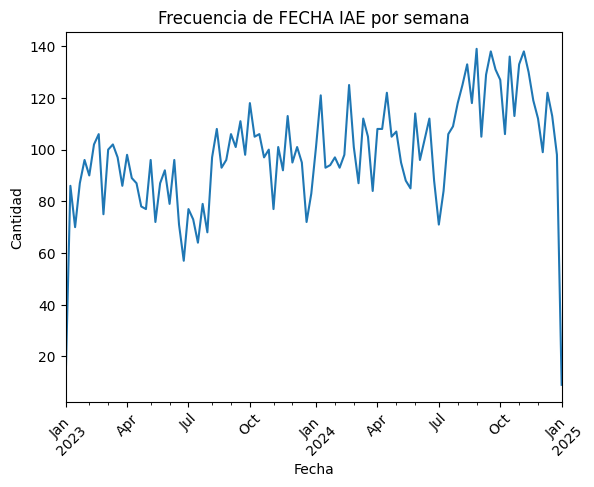

In [559]:
#df_IAE['FECHA IAE'].value_counts()
#conteo = df_IAE['REGISTRO'].dt.date.value_counts().sort_index() # por día
#conteo_semanal = df_IAE.set_index('FECHA IAE').resample('W').size()

#plt.figure()
#conteo_semanal.plot()
#plt.xlabel("Fecha")
#plt.ylabel("Cantidad")
#plt.title("Cantidad de intentos por semana")
#plt.xticks(rotation=45)
#plt.show()

graficar_segun_fecha(df_IAE, 'FECHA IAE', 'W')

In [560]:
mostrar_unicos(df_IAE,'METODO')
mostrar_frecuencias(df_IAE,'METODO')

METODO tiene 6 valores únicos.
['Lesiones autoinfligidas' 'Ingesta de Medicamentos' 'Otros'
 'Arma de fuego' 'Ahorcamiento o asfixia' 'otros']
METODO
Ingesta de Medicamentos    7504
Otros                      1032
Lesiones autoinfligidas     934
Ahorcamiento o asfixia      902
Arma de fuego                44
otros                         1
Name: count, dtype: int64


In [561]:
df_IAE['METODO'].value_counts().head(20)

METODO
Ingesta de Medicamentos    7504
Otros                      1032
Lesiones autoinfligidas     934
Ahorcamiento o asfixia      902
Arma de fuego                44
otros                         1
Name: count, dtype: int64

In [562]:
df_IAE = acondicionar_atributo_metodo(df_IAE)

In [563]:
mostrar_frecuencias(df_IAE, 'METODO')

METODO
Ingesta de Medicamentos    7504
Otros                      1033
Lesiones autoinfligidas     934
Ahorcamiento o asfixia      902
Armas de fuego               44
Name: count, dtype: int64


In [618]:
#categorias = ['Ingesta de Medicamentos', 'Ahorcamiento o asfixia','Lesiones autoinfligidas', 'Armas de fuego', 'Caída']
#df_IAE['METODO_'] = df_IAE['METODO'].where(df_IAE['METODO'].isin(categorias), 'Otros')
df_IAE = agregar_categoria_metodo(df_IAE)
mostrar_frecuencias(df_IAE, 'METODO_')

METODO_
Ingesta de Medicamentos    7504
Otros                      1033
Lesiones autoinfligidas     934
Ahorcamiento o asfixia      902
Armas de fuego               44
Name: count, dtype: int64


In [619]:
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].str.strip() # Elimino espacios antes y después de los string
#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('IAE PREVIO','Tratamiento')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace(palabras_a_reemplazar,'Tratamiento')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace('Sin dato','NO SE INDICA')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace('','NO SE INDICA')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].fillna("NO SE INDICA")

mostrar_frecuencias(df_IAE,'IAE PREVIO')
df_IAE = acondicionar_IAE_PREVIO(df_IAE)
mostrar_frecuencias(df_IAE,'IAE PREVIO')
mostrar_unicos(df_IAE,'IAE PREVIO')

IAE PREVIO
SI              5320
NO              3496
NO SE INDICA    1601
Name: count, dtype: int64
IAE PREVIO
SI              5320
NO              3496
NO SE INDICA    1601
Name: count, dtype: int64
IAE PREVIO tiene 3 valores únicos.
['SI' 'NO' 'NO SE INDICA']


In [620]:
mostrar_valores_nulos(df_IAE,campo_nacimiento)

NACIMIENTO tiene 1 valores nulos


In [621]:
#df_IAE['FECHA IAE'] = pd.to_datetime(df_IAE['FECHA IAE'], errors='coerce')
#df_IAE[campo_nacimiento] = pd.to_datetime(df_IAE[campo_nacimiento], errors='coerce')
#df_IAE['EDAD_'] = df_IAE['FECHA IAE'].dt.year - df_IAE[campo_nacimiento].dt.year
df_IAE = calcular_y_agregar_campo_edad(df_IAE, 'FECHA IAE', campo_nacimiento)
mostrar_rango(df_IAE, 'EDAD_')

El rango del atributo EDAD_ es [6.0, 103.0]


In [622]:
coincidencias_edades = np.sum(df_IAE['EDAD_']==df_IAE['EDAD'])
print(f'Coinciden {coincidencias_edades} de {len(df_IAE['EDAD_'])} edades')

Coinciden 5468 de 10417 edades


In [623]:
campo_edad = 'EDAD_' if dataset==2 else 'EDAD' 
#edades_IAE = df_IAE[campo_edad].unique()
#print(edades_IAE)
#print(np.nanmin(edades_IAE), np.nanmax(edades_IAE))
#print(np.sum(np.isnan(edades_IAE)))
mostrar_unicos(df_IAE, campo_edad)
mostrar_rango(df_IAE, campo_edad)

EDAD tiene 93 valores únicos.
[ 15.  33.  17.  65.  26.  72.  27.  19.  14.  28.  25.  57.  21.  20.
  18.  49.  75.  13.  60.  22.  48.  42.  69.  40.  80.  41.  36.  38.
  16.  54.  31.  32.  43.  84.  51.  55.  30.  52.  24.  37.  50.  66.
  61.  23.  46.  29.  53.  11.  34.  58.  47.  83.  nan  56.  70.  44.
  39.  63.  67.  59.  68.  76.  91.  35.  62.  10.   8.  45.  74.  90.
  77.  64.  94.  71.  12.  79.  86.  81.  78.  89.  73.  87.  85.  82.
   7.   9.  88. 102.  93.   6.  95.   5.  92.]
El rango del atributo EDAD es [5.0, 102.0]


In [624]:
df_IAE = discretizar(df_IAE, campo_edad, "GRUPO_EDAD_", 5)

In [625]:
# como esta columna contiene información del resultado (Suicidio o no), me quedan dudas de si es conveniente usarla para predecir. 
# Llama la aención la cantidad de casos en que no se cumple protocolo


#df_IAE[campo_decision] = df_IAE[campo_decision].str.strip() #saco espacios adelante y atras
#df_IAE[campo_decision].value_counts()

In [626]:
df_IAE = acondicionar_campo_DECISION(df_IAE, campo_decision)
mostrar_unicos(df_IAE, campo_decision)
mostrar_frecuencias(df_IAE, campo_decision)
#filas_unicas

DECISIÓN tiene 12 valores únicos.
['RESUELTO' 'NO CUMPLE PROTOCOLO' 'PENDIENTE RESPUESTA' 'INTERNADO'
 'RESUELT0' 'SIN COBERTURA ASISTENCIAL' 'SUICIDIO'
 'SIN DATOS ASISTENCIALES' 'PRIVADO DE LIBERTAD'
 'NO EXISTE MÁS EN EXPORTADA' 'SEG PARTICULAR' 'RESPUESTA']
DECISIÓN
RESUELTO                      6166
NO CUMPLE PROTOCOLO           2650
PENDIENTE RESPUESTA           1384
INTERNADO                      153
SIN COBERTURA ASISTENCIAL       35
SUICIDIO                        20
SIN DATOS ASISTENCIALES          4
RESUELT0                         1
PRIVADO DE LIBERTAD              1
NO EXISTE MÁS EN EXPORTADA       1
SEG PARTICULAR                   1
RESPUESTA                        1
Name: count, dtype: int64


In [627]:
# se agrupan las decisiones

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'RESUELTO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'RESUELTO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'NO CUMPLE')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'NO CUMPLE PROTOCOLO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'SUICIDIO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'SUICIDIO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'INTERNAD')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'INTERNADO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('INTERNADO ','INTERNADO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('PENDIENTE INTERNADO','INTERNADO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'PENDIENTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'PENDIENTE RESPUESTA')
#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'PENDEINTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'PENDIENTE RESPUESTA')

#df_IAE[campo_decision] = df_IAE[campo_decision].replace('SIN RESPUESTA DEFINITIVA','PENDIENTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('SIN RESPUESTA','PENDIENTE RESPUESTA')


#df_IAE[campo_decision].unique()

In [628]:
# se crea una nueva columna DECISION_ con 6 categorías.
#df_IAE['DECISION_'] = df_IAE[campo_decision].copy()

#categorias = ['RESUELTO', 'NO CUMPLE PROTOCOLO','PENDIENTE RESPUESTA','INTERNADO', 'SUICIDIO']
#df_IAE['DECISION_'] = df_IAE['DECISION_'].where(df_IAE['DECISION_'].isin(categorias), 'OTRA DECISION')

agregar_campo_DECISION(df_IAE, campo_decision, 'DECISION_')
mostrar_unicos(df_IAE,campo_decision)
mostrar_frecuencias(df_IAE,campo_decision)
mostrar_unicos(df_IAE, 'DECISION_')
mostrar_frecuencias(df_IAE, 'DECISION_')

DECISIÓN tiene 12 valores únicos.
['RESUELTO' 'NO CUMPLE PROTOCOLO' 'PENDIENTE RESPUESTA' 'INTERNADO'
 'RESUELT0' 'SIN COBERTURA ASISTENCIAL' 'SUICIDIO'
 'SIN DATOS ASISTENCIALES' 'PRIVADO DE LIBERTAD'
 'NO EXISTE MÁS EN EXPORTADA' 'SEG PARTICULAR' 'RESPUESTA']
DECISIÓN
RESUELTO                      6166
NO CUMPLE PROTOCOLO           2650
PENDIENTE RESPUESTA           1384
INTERNADO                      153
SIN COBERTURA ASISTENCIAL       35
SUICIDIO                        20
SIN DATOS ASISTENCIALES          4
RESUELT0                         1
PRIVADO DE LIBERTAD              1
NO EXISTE MÁS EN EXPORTADA       1
SEG PARTICULAR                   1
RESPUESTA                        1
Name: count, dtype: int64
DECISION_ tiene 6 valores únicos.
['RESUELTO' 'NO CUMPLE PROTOCOLO' 'PENDIENTE RESPUESTA' 'INTERNADO'
 'OTRA DECISION' 'SUICIDIO']
DECISION_
RESUELTO               6166
NO CUMPLE PROTOCOLO    2650
PENDIENTE RESPUESTA    1384
INTERNADO               153
OTRA DECISION            44
SU

In [629]:
#df_IAE['IAE PREVIO'].value_counts()
mostrar_frecuencias(df_IAE, 'IAE PREVIO')
mostrar_unicos(df_IAE, 'IAE PREVIO')

IAE PREVIO
SI              5320
NO              3496
NO SE INDICA    1601
Name: count, dtype: int64
IAE PREVIO tiene 3 valores únicos.
['SI' 'NO' 'NO SE INDICA']


In [630]:
#df_IAE["DEFUNCION_"] = df_IAE["CEDULA"].isin(df_IAE_CDE["cedula"]).astype(int)
#print(np.sum(df_IAE["DEFUNCION_"])) # 309 intentos asociados a personas fallecidas
                                    # 4756 intentos asociados a personas fallecidas en la segunda entrega!!

df_IAE = agregar_si_intentos_en_CDE(df_IAE, df_IAE_CDE, 'IAEinCDE')                                    

Se agrego el campo IAEinCDE que vale 1 si la persona falleció (no necesariamente suicidio)
309 de los 10417 intentos están asociados a personas fallecidas


In [631]:
df_IAE_CDE.head()

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,CAT_SUI_,CAT_MCEXSUI_,grupo edades_
0,003de44dcaf4c586037122e3a35be455a1356865866018...,2024-10-22,R961,MUERTE QUE OCURRE EN MENOS DE 24 HORAS DEL INI...,DOMICILIO,NaN,CA,73.0,73.0,0,0,72.5
1,011cd0f600c0d9c8365730048714df403bbee1bfcc0a83...,2025-07-04,V445,OCUPANTE DE AUTOMÓVIL LESIONADO POR COLISIÓN C...,VÍA PÚBLICA,NaN,DU,55.0,55.0,0,1,57.5
2,014821c7f384cec65f2d9f1c3bf4a837d651d1152572f6...,2023-06-29,R961,MUERTE QUE OCURRE EN MENOS DE 24 HORAS DEL INI...,CENTRO ASISTENCIAL,NaN,CO,84.0,84.0,0,0,82.5
3,02052fdd2019ec4ba7cbb048a357b27c99a985b39b4707...,2023-08-07,Y218,"AHOGAMIENTO Y SUMERSIÓN, DE INTENCIÓN NO DETER...",VÍA PÚBLICA,NaN,MO,37.0,37.0,0,0,37.5
4,02b6dcc5b9fbe88bbd4cfd6e3ccd8dcffde35c0123562b...,2023-02-12,X708,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,OTRO,Campo,CA,46.0,46.0,1,0,47.5


In [632]:
#df_IAE["FECHA_DEFUNCION"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["fecha_defuncion"])
#df_IAE["CAUSA_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["causa_basica_muerte_valor"])
#df_IAE["DPTO_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["departamento_ocurrencia"])
#df_IAE["EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["edad_fallecimiento_digitada"])
#df_IAE["GRUPO_EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["grupo edades"])
#df_IAE["MOTIVO_EXTERNO_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["motivo_externo"])
#df_IAE["MOTIVO_EXT_SUI_"] = df_IAE["MOTIVO_EXTERNO_"]=='SUICIDIO'
#df_IAE["ES_MOTIVO_EXTERNO_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["es_motivo_externo"])
#df_IAE["CAT_SUI_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["CAT_SUI_"])
#df_IAE["CAT_MCEXSUI_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["CAT_MCEXSUI_"])

df_IAE = agregar_datos_CDE_en_IAE(df_IAE, df_IAE_CDE, dataset)


In [633]:
if dataset==2:
    mostrar_frecuencias(df_IAE_CDE, "MOTIVO_EXTERNO_")
    mostrar_frecuencias(df_IAE_CDE, "MOTIVO_EXT_SUI_")
    df_IAE.loc[df_IAE['PRESTADOR'].isnull(), 'DEFUNCION_'].value_counts()
    df_IAE.loc[df_IAE['PRESTADOR_PRIVADO_'].isnull(), 'ES_MOTIVO_EXTERNO_'].value_counts()

In [634]:
#df_IAE['IAE PREVIO'].value_counts()
mostrar_frecuencias(df_IAE, 'IAE PREVIO')

IAE PREVIO
SI              5320
NO              3496
NO SE INDICA    1601
Name: count, dtype: int64


In [635]:
if dataset==2:
    df_IAE[df_IAE['IAE PREVIO']=='NO SE INDICA']['ES_MOTIVO_EXTERNO_'].value_counts()
    df_IAE["CAT_SUI_"].sum(), df_IAE["CAT_MCEXSUI_"].sum(), df_IAE["DEFUNCION_"].sum(), df_IAE["MOTIVO_EXTERNO_"].value_counts().sum()
    mostrar_valores_nulos(df_IAE, "CAT_SUI_")

In [636]:
df_IAE.columns

Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
       'FECHA IAE', 'EDAD', 'DECISIÓN', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAEinCDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_'],
      dtype='object')

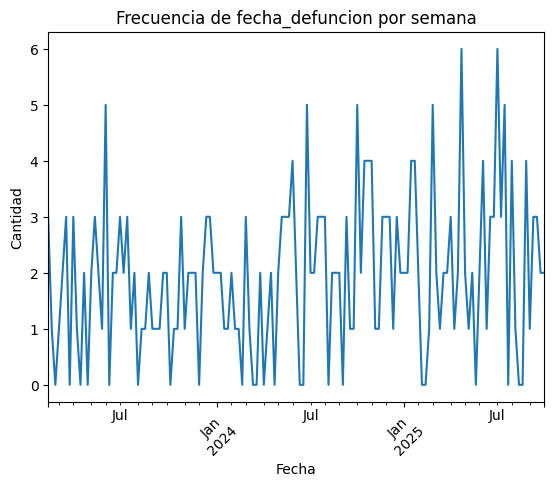

In [637]:

if dataset==1:
    graficar_segun_fecha(df_IAE_CDE,'fecha_defuncion','W')

In [638]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10417 entries, 0 to 10426
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype          
---  ------                    --------------  -----          
 0   CEDULA                    10417 non-null  object         
 1   PERSONA                   10417 non-null  object         
 2   NACIMIENTO                10416 non-null  datetime64[ns] 
 3   PRESTADOR RECODIFICADO    10414 non-null  object         
 4   ESTABLECIMIENTO REGISTRO  7501 non-null   object         
 5   REGISTRO                  10417 non-null  datetime64[ns] 
 6   METODO                    10417 non-null  object         
 7   IAE PREVIO                10417 non-null  object         
 8   FECHA IAE                 10417 non-null  datetime64[ns] 
 9   EDAD                      10416 non-null  float64        
 10  DECISIÓN                  10417 non-null  object         
 11  Tipo_prestador_IAE_       10414 non-null  object         
 12  PRESTADOR

In [639]:
# días que transcurren desde el IAE hasta la muerte. Si la persona no murió se pone nan
#df_IAE['DIAS_IAE_MUERTE_'] = (df_IAE["FECHA_DEFUNCION"] - df_IAE["FECHA IAE"])

df_IAE = agregar_dias_IAE_a_muerte(df_IAE)

In [640]:
df_IAE.loc[df_IAE['DIAS_IAE_MUERTE_'].dt.days<0, ['FECHA IAE', 'FECHA_DEFUNCION']]

,FECHA IAE,FECHA_DEFUNCION


In [641]:
#df_IAE['DIAS_IAE_MUERTE_'].unique()  # días transcurridos desde un IAE hasta muerte
mostrar_unicos(df_IAE,'DIAS_IAE_MUERTE_')

DIAS_IAE_MUERTE_ tiene 232 valores únicos.
<TimedeltaArray>
[       NaT,  '66 days', '485 days',  '58 days',  '17 days',  '37 days',
 '495 days',   '0 days',   '9 days',   '1 days',
 ...
 '695 days', '178 days',  '43 days', '656 days', '475 days', '744 days',
 '479 days', '616 days', '151 days', '719 days']
Length: 232, dtype: timedelta64[ns]


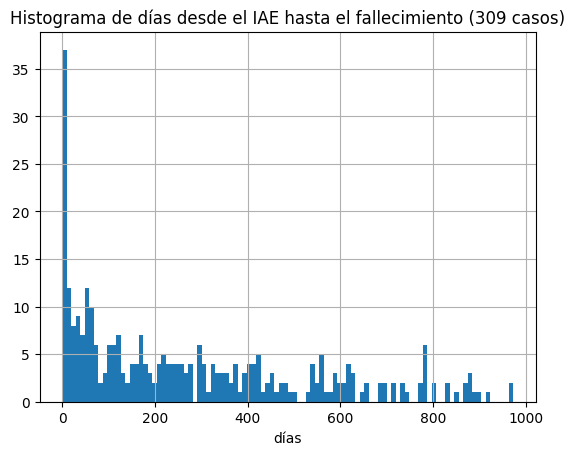

In [642]:
plt.figure()
df_IAE['DIAS_IAE_MUERTE_'].dt.days.hist(bins=100)
n_casos = df_IAE['DIAS_IAE_MUERTE_'].value_counts().sum()
plt.title(f'Histograma de días desde el IAE hasta el fallecimiento ({n_casos} casos)')
plt.xlabel('días')
plt.show()

In [643]:
df_IAE.keys()

Index(['CEDULA', 'PERSONA', 'NACIMIENTO', 'PRESTADOR RECODIFICADO',
       'ESTABLECIMIENTO REGISTRO', 'REGISTRO', 'METODO', 'IAE PREVIO',
       'FECHA IAE', 'EDAD', 'DECISIÓN', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAEinCDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_'],
      dtype='object')

In [644]:
if dataset==2:
    df_IAE.loc[indices_malos, 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO'].value_counts()

In [645]:
bad = df_IAE[df_IAE.isna().sum(axis=1) > 24]
bad.dropna(axis=1, how='all')

""


In [646]:
df_IAE_agregada = agregar_base_intentos(df_IAE, dataset)

In [649]:
agregar_campo(df_IAE,'METODO',ultimo_intento,'ULTIMO_INTENTO_')

,nombre_nuevo_atributo
CEDULA,
0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2,Lesiones autoinfligidas
00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22,Ingesta de Medicamentos
00133099d10f0d6d56bd2f58267ff271fd097b1682638fc7405967ed68fbeff5,Ingesta de Medicamentos
001eecb0c2ccec125edf01c7c069aa76d7865cae45be71efe20ec50640eb6686,Otros
0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f0c6d700d1e39bc77db,Ingesta de Medicamentos
...,...
ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d4576cfa58780f7c357,Ahorcamiento o asfixia
ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb598b755045e8c6ff56,Lesiones autoinfligidas
fff6eeeb39dc05fc78a98f367f478045ccf8835a538565f47ba0949106157136,Ingesta de Medicamentos


In [650]:
df_IAE_agregada['METODO_IAE_PREVIO_3_'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8827 entries, 0 to 8826
Series name: METODO_IAE_PREVIO_3_
Non-Null Count  Dtype 
--------------  ----- 
296 non-null    object
dtypes: object(1)
memory usage: 69.1+ KB


In [651]:
df_IAE_agregada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     7721
2      810
3      193
4       60
5       22
6       13
9        3
10       2
7        2
8        1
Name: count, dtype: int64

In [652]:
df_IAE['DIAS_IAE_MUERTE_'].value_counts()

DIAS_IAE_MUERTE_
4 days      7
1 days      6
0 days      6
2 days      6
9 days      4
           ..
744 days    1
479 days    1
616 days    1
151 days    1
719 days    1
Name: count, Length: 231, dtype: int64

In [654]:
mostrar_frecuencias(df_IAE_agregada,'MIN_DIAS_IAE_MUERTE_')

MIN_DIAS_IAE_MUERTE_
4 days      7
1 days      6
0 days      6
2 days      6
9 days      4
           ..
744 days    1
479 days    1
616 days    1
151 days    1
719 days    1
Name: count, Length: 205, dtype: int64


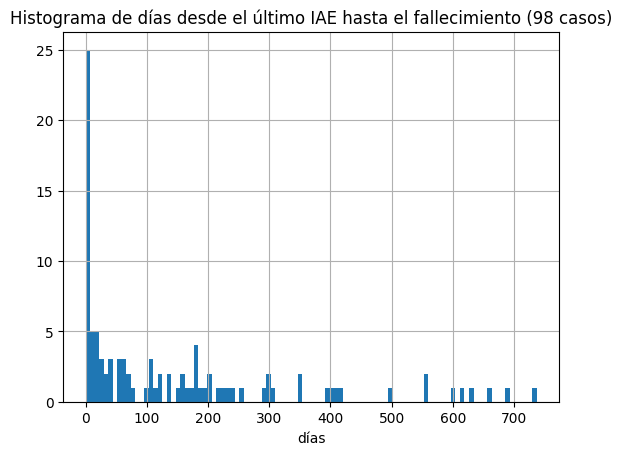

In [655]:
plt.figure()
df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1]['MIN_DIAS_IAE_MUERTE_'].dt.days.hist(bins=100)
n_casos = df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1]['MIN_DIAS_IAE_MUERTE_'].value_counts().sum()
plt.title(f'Histograma de días desde el último IAE hasta el fallecimiento ({n_casos} casos)')
plt.xlabel('días')
plt.show()

In [661]:
#indices = df_IAE_agregada['CEDULA'].isin(df_IAE_CDE['cedula'])
#f_IAE_agregada[~indices].shape 

personas_con_IAE_no_presentes_en_CDE(df_IAE_agregada, df_IAE_CDE)

Hay 8560 personas con IAE no presentes en CDE.


,CEDULA,Sexo,NACIMIENTO,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,PRESTADOR_PUBLICO_,...,FECHA_DEFUNCION,NUMERO_INTENTOS_,DECISION_,IAEinCDE_,CAT_SUI_,CAT_MCEXSUI_,GRUPO_EDAD_,ULTIMO_INTENTO_,DIAS_PROMEDIO_INTENTOS_,MIN_DIAS_IAE_MUERTE_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,True,...,NaT,1,RESUELTO,0,NaN,NaN,17.5,2023-05-22,NaN,NaT
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,False,...,NaT,1,RESUELTO,0,NaN,NaN,32.5,2024-07-22,NaN,NaT
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,True,...,NaT,1,NO CUMPLE PROTOCOLO,0,NaN,NaN,17.5,2024-10-02,NaN,NaT
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,Otros,Otros,None,None,NO,COMECA IAMPP,False,...,NaT,1,PENDIENTE RESPUESTA,0,NaN,NaN,17.5,2023-05-15,NaN,NaT
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,ASSE - SALTO,True,...,NaT,1,RESUELTO,0,NaN,NaN,67.5,2023-08-07,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8822,ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d...,Femenino,1998-04-01,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO,ASSE - PAYSANDU,True,...,NaT,1,NO CUMPLE PROTOCOLO,0,NaN,NaN,27.5,2024-03-19,NaN,NaT
8823,ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb...,Femenino,2009-05-01,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,COMERO,False,...,NaT,1,RESUELTO,0,NaN,NaN,17.5,2024-08-31,NaN,NaT
8824,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,None,SI,CASMU,False,...,NaT,2,RESUELTO,0,NaN,NaN,57.5,2024-06-17,521.0,NaT
8825,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Femenino,1995-07-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,ASSE - SD,True,...,NaT,1,PENDIENTE RESPUESTA,0,NaN,NaN,27.5,2023-09-12,NaN,NaT


In [673]:
indices = df_IAE_CDE['cedula'].isin(df_IAE_agregada['CEDULA'])
personas = df_IAE_CDE[~indices]

In [674]:
personas_en_CDE_sin_IAE(df_IAE_agregada, df_IAE_CDE)

Hay 2 personas en CDE que no están en la base de IAE.


,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,CAT_SUI_,CAT_MCEXSUI_,grupo edades_
37,21c2eedd94ddf081962ebffb62052a32f17e67afb77f31...,2023-03-19,C800,"TUMOR MALIGNO, DE SITIO PRIMARIO DESCONOCIDO, ...",CENTRO ASISTENCIAL,NaN,DU,62.0,62.0,0,0,62.5
172,acb54dd66c3165a41def528880af8e16e98da8ece2c6d9...,2023-06-25,X700,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,CENTRO ASISTENCIAL,NaN,MO,37.0,37.0,1,0,37.5


In [680]:
df_IAE_agregada[df_IAE_agregada['PRESTADOR_PUBLICO_']==1]['IAEinCDE_'].value_counts()

IAEinCDE_
0    3831
1     123
Name: count, dtype: int64

In [681]:
df_IAE_agregada[df_IAE_agregada['MIN_DIAS_IAE_MUERTE_']< pd.Timedelta(days=0)]

,CEDULA,Sexo,NACIMIENTO,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,PRESTADOR_PUBLICO_,...,FECHA_DEFUNCION,NUMERO_INTENTOS_,DECISION_,IAEinCDE_,CAT_SUI_,CAT_MCEXSUI_,GRUPO_EDAD_,ULTIMO_INTENTO_,DIAS_PROMEDIO_INTENTOS_,MIN_DIAS_IAE_MUERTE_


In [682]:
df_IAE_agregada['IAEinCDE_'].value_counts()

IAEinCDE_
0    8560
1     267
Name: count, dtype: int64

In [683]:
df_IAE_agregada.set_index('FECHA_DEFUNCION').resample('W').size()

FECHA_DEFUNCION
2023-02-12    3
2023-02-19    1
2023-02-26    0
2023-03-05    1
2023-03-12    2
             ..
2025-09-07    1
2025-09-14    3
2025-09-21    3
2025-09-28    2
2025-10-05    2
Length: 139, dtype: int64

In [687]:
if dataset==2:
    #conteo_semanal_defunciones = df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1].set_index('FECHA_DEFUNCION').resample('W').size()

    #plt.figure()
    #conteo_semanal_defunciones.plot()
    #plt.xlabel("Fecha")
    #plt.ylabel("Cantidad")
    #plt.title("Cantidad de fallecimientos por semana")
    #plt.xticks(rotation=45)
    #plt.show()

    graficar_segun_fecha(df_IAE_agregada,'FECHA_DEFUNCION','W')

In [689]:
df_IAE_agregada.head()

,CEDULA,Sexo,NACIMIENTO,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,PRESTADOR_PUBLICO_,...,FECHA_DEFUNCION,NUMERO_INTENTOS_,DECISION_,IAEinCDE_,CAT_SUI_,CAT_MCEXSUI_,GRUPO_EDAD_,ULTIMO_INTENTO_,DIAS_PROMEDIO_INTENTOS_,MIN_DIAS_IAE_MUERTE_
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,True,...,NaT,1,RESUELTO,0,NaN,NaN,17.5,2023-05-22,NaN,NaT
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,False,...,NaT,1,RESUELTO,0,NaN,NaN,32.5,2024-07-22,NaN,NaT
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,True,...,NaT,1,NO CUMPLE PROTOCOLO,0,NaN,NaN,17.5,2024-10-02,NaN,NaT
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,Otros,Otros,None,None,NO,COMECA IAMPP,False,...,NaT,1,PENDIENTE RESPUESTA,0,NaN,NaN,17.5,2023-05-15,NaN,NaT
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,ASSE - SALTO,True,...,NaT,1,RESUELTO,0,NaN,NaN,67.5,2023-08-07,NaN,NaT


In [691]:
#df_IAE_agregada['DIAS_PROMEDIO_INTENTOS_'].unique()
mostrar_unicos(df_IAE_agregada,'DIAS_PROMEDIO_INTENTOS_')

DIAS_PROMEDIO_INTENTOS_ tiene 511 valores únicos.
[         nan 329.          80.         248.         137.2
 227.5        303.         170.         126.          77.5
  19.           2.          34.          21.         617.
   8.          37.         217.         427.         144.5
 128.66666667 218.         128.           1.         278.
  45.         181.          15.         380.           0.
 169.         140.         127.         174.          16.5
   9.         216.         145.33333333  35.          24.
 512.          14.          33.          58.         136.
 345.         162.          59.66666667 164.         354.
 205.         306.5        117.         196.          90.
 534.          41.5        202.         207.         120.
  29.         132.5        273.         150.         219.
  30.         401.         182.         173.          24.8
 157.         106.5        352.          23.         298.
 183.         115.         212.         289.         308.
   6.         266

In [693]:
np.sum(df_IAE_agregada['IAEinCDE_']==1)

np.int64(267)

In [697]:
# Cuadro 2A en el informe
df_IAE_agregada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     7721
2      810
3      193
4       60
5       22
6       13
9        3
10       2
7        2
8        1
Name: count, dtype: int64

In [699]:
mostrar_frecuencias(df_IAE_agregada, 'IAE_PREVIO')

IAE_PREVIO
SI              4275
NO              3137
NO SE INDICA    1415
Name: count, dtype: int64


In [701]:
#df_IAE_agregada['IAE_PREVIO_CORREGIDO' ] = df_IAE_agregada['IAE_PREVIO'].copy()
#df_IAE_agregada.loc[(df_IAE_agregada["IAE_PREVIO_CORREGIDO"] == "NO SE INDICA") & (df_IAE_agregada["NUMERO_INTENTOS_"] > 0), "IAE_PREVIO_CORREGIDO"] = "SI"

df_IAE_agregada = agregar_IAE_PREVIO_corregido(df_IAE_agregada)

In [702]:
df_IAE['IAE PREVIO'].shape, df_IAE_agregada['IAE_PREVIO'].shape

((10417,), (8827,))

In [703]:
df_IAE['IAE PREVIO'].value_counts().sum()

np.int64(10417)

In [704]:
df_IAE_agregada['IAE_PREVIO'].value_counts().sum()

np.int64(8827)

In [705]:
df_IAE_agregada['IAE_PREVIO_CORREGIDO'].value_counts()

IAE_PREVIO_CORREGIDO
SI    5690
NO    3137
Name: count, dtype: int64

In [706]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO']=='NO SE INDICA', 'IAEinCDE_'].value_counts()

IAEinCDE_
0    1356
1      59
Name: count, dtype: int64

In [707]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO']=='NO SE INDICA', 'NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1    1334
2      66
3      11
4       2
5       1
9       1
Name: count, dtype: int64

In [708]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO_CORREGIDO']=='NO SE INDICA', 'IAEinCDE_'].value_counts()

Series([], Name: count, dtype: int64)

In [709]:
df_IAE_agregada['METODO_IAE_FRECUENTE_'].value_counts()

METODO_IAE_FRECUENTE_
Ingesta de Medicamentos    6400
Ahorcamiento o asfixia      834
Otros                       822
Lesiones autoinfligidas     731
Armas de fuego               40
Name: count, dtype: int64

In [710]:
df_IAE_agregada['METODO_IAE_PREVIO_'].value_counts()

METODO_IAE_PREVIO_
Ingesta de Medicamentos    6301
Otros                       918
Ahorcamiento o asfixia      792
Lesiones autoinfligidas     777
Armas de fuego               39
Name: count, dtype: int64

In [711]:
nombre_procesada = 'IAE_agregada_2a_entrega.csv' if dataset==2 else 'IAE_agregada.csv'
df_IAE_agregada.to_csv(nombre_procesada)

# Análisis IAE CNV

In [773]:
df_IAE_CNV.shape

(3262, 2)

In [791]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3220 entries, 0 to 3260
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   cedula                    3220 non-null   object        
 1   anio_mes_nacimiento_hijo  3220 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 75.5+ KB


In [792]:
#df_IAE_CNV=df_IAE_CNV.dropna(thresh=2) 
df_IAE_CNV = conservar_filas_con_n_no_nulos(df_IAE_CNV, 2)

La base tenía 3220 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 3220 filas


In [793]:
df_IAE_CNV.shape

(3220, 2)

In [794]:
np.sum(df_IAE_CNV['cedula'].isnull())

np.int64(0)

In [795]:
# regionales de ASSE

In [796]:
df_IAE_CNV[df_IAE_CNV['cedula']=='62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085']

# cantidad de hijos
# edad más pequeño # ¿paridad completa?
# predecir reintento?

,cedula,anio_mes_nacimiento_hijo
1653,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2008-04-01
1654,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2011-09-01
1655,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2013-05-01
1656,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2015-09-01
1657,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2017-10-01
1658,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2020-11-01


In [797]:
mostrar_frecuencias(df_IAE_CNV,'cedula')

cedula
62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085    6
fc198870f88665e7c7867bee855b485f74c9f89bce2f1ab88e51937f9bbc301e    6
4864459a09c1d5ccb39caf4a87c17a19a8f344aaa3506fbe6a0bc4d3dfb31ccd    6
594a32685f6323be7dc9fd0b5e9430d9e11365876cf428f96f5791aa36fd6150    5
9e0578a1a0fd281b257b4a0ba31fd9f41a0c76d47f69ea727dbd6b6516e5d76c    5
                                                                   ..
46e587282ebd315d55dc3b91ceb07e18aa5d03f8e7ff52c742923cb150c8d84e    1
899fc9f0ad254fff843d2bb706333d0385ea54837e447ba00009f4ab316da4e6    1
5a33a5d5b1df559b57d8dbd11ff8c54707167011bdd2ed72a761eac980ee3d56    1
a1fb4ba2b809cd4a1ceb33cebd44e847f7425a2d814807dd5af62a2cdb4edbd6    1
50f55c8998f6d00205e3ced2857afae5b3d4db5ba89760419640ddc7b8730f86    1
Name: count, Length: 2127, dtype: int64


In [798]:
# Hay 41 duplicados
#df_IAE_CNV.drop_duplicates(inplace=True)
df_IAE_CNV = eliminar_duplicados(df_IAE_CNV)
df_IAE_CNV.shape

Se eliminaron 0 filas duplicadas en la base. Ahora la base tiene 3220 filas.


(3220, 2)

In [799]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3220 entries, 0 to 3260
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   cedula                    3220 non-null   object        
 1   anio_mes_nacimiento_hijo  3220 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 75.5+ KB


In [800]:
np.sum(df_IAE_CNV.duplicated())

np.int64(0)

In [801]:
df_IAE_CNV['anio_mes_nacimiento_hijo'].unique()

<DatetimeArray>
['2010-08-01 00:00:00', '2014-01-01 00:00:00', '2011-06-01 00:00:00',
 '2008-08-01 00:00:00', '2011-08-01 00:00:00', '2012-08-01 00:00:00',
 '2012-11-01 00:00:00', '2012-12-01 00:00:00', '2014-06-01 00:00:00',
 '2015-09-01 00:00:00',
 ...
 '2023-10-01 00:00:00', '2023-04-01 00:00:00', '2025-07-01 00:00:00',
 '2024-05-01 00:00:00', '2024-01-01 00:00:00', '2008-03-01 00:00:00',
 '2024-03-01 00:00:00', '2025-08-01 00:00:00', '2024-04-01 00:00:00',
 '2025-10-01 00:00:00']
Length: 212, dtype: datetime64[ns]

In [802]:
indices = df_IAE_CNV['cedula'].isin(df_IAE_agregada['CEDULA'])
personas_de_IAE_no_presentes_en_CNV = df_IAE_CNV[~indices]

In [803]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo'], dtype='object')

In [805]:
#indices = df_IAE_CNV['cedula'].isin(df_IAE_agregada['CEDULA'])
#df_IAE_CNV[~indices].shape  # hay 20 cédulas que están en la base de CNV pero no están en la de IAE
                            # en la segunda entrega no hay cédulas que están en la base de CNV pero no están en la de IAE  
personas = personas_en_CNV_sin_IAE(df_IAE_agregada, df_IAE_CNV)                            

Hay 20 personas en CNV que no están en la base de IAE.


In [807]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_CNV['cedula'])
#df_IAE_procesada[~indices].shape   # en la segunda entrega hay 13148 cédulas que están en la base de de IAE  pero no están en la CNV   
personas = personas_con_IAE_no_presentes_en_CNV(df_IAE_agregada, df_IAE_CNV)    

Hay 6711 personas con IAE no presentes en CNV.


In [811]:
indices = df_IAE_agregada['CEDULA'].isin(df_IAE_CNV['cedula'])
df_IAE_agregada.loc[~indices,'FECHA_IAE'].isnull().sum()

np.int64(0)

In [812]:
df_IAE_agregada.keys()

Index(['CEDULA', 'Sexo', 'NACIMIENTO', 'METODO_IAE_FRECUENTE_',
       'METODO_IAE_PREVIO_', 'METODO_IAE_PREVIO_2_', 'METODO_IAE_PREVIO_3_',
       'IAE_PREVIO', 'PRESTADOR_RECODIFICADO', 'PRESTADOR_PUBLICO_',
       'PRESTADOR_PRIVADO_', 'REGISTRO', 'FECHA_IAE', 'FECHA_DEFUNCION',
       'NUMERO_INTENTOS_', 'DECISION_', 'IAEinCDE_', 'CAT_SUI_',
       'CAT_MCEXSUI_', 'GRUPO_EDAD_', 'ULTIMO_INTENTO_',
       'DIAS_PROMEDIO_INTENTOS_', 'MIN_DIAS_IAE_MUERTE_',
       'IAE_PREVIO_CORREGIDO'],
      dtype='object')

In [813]:
df_IAE_agregada.loc[indices,'IAEinCDE_'].value_counts()

IAEinCDE_
0    2085
1      31
Name: count, dtype: int64

In [814]:
mostrar_frecuencias(df_IAE_CNV, 'cedula')

cedula
62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085    6
fc198870f88665e7c7867bee855b485f74c9f89bce2f1ab88e51937f9bbc301e    6
4864459a09c1d5ccb39caf4a87c17a19a8f344aaa3506fbe6a0bc4d3dfb31ccd    6
594a32685f6323be7dc9fd0b5e9430d9e11365876cf428f96f5791aa36fd6150    5
9e0578a1a0fd281b257b4a0ba31fd9f41a0c76d47f69ea727dbd6b6516e5d76c    5
                                                                   ..
46e587282ebd315d55dc3b91ceb07e18aa5d03f8e7ff52c742923cb150c8d84e    1
899fc9f0ad254fff843d2bb706333d0385ea54837e447ba00009f4ab316da4e6    1
5a33a5d5b1df559b57d8dbd11ff8c54707167011bdd2ed72a761eac980ee3d56    1
a1fb4ba2b809cd4a1ceb33cebd44e847f7425a2d814807dd5af62a2cdb4edbd6    1
50f55c8998f6d00205e3ced2857afae5b3d4db5ba89760419640ddc7b8730f86    1
Name: count, Length: 2127, dtype: int64


In [815]:
df_IAE[df_IAE['CEDULA']=='89b56b020597ddb182c77ec7de8c24c18c965eebd6a94a36553ba12b7b3158db']

,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN


In [816]:
df_IAE_CNV['cedula'].value_counts(0)

cedula
62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085    6
fc198870f88665e7c7867bee855b485f74c9f89bce2f1ab88e51937f9bbc301e    6
4864459a09c1d5ccb39caf4a87c17a19a8f344aaa3506fbe6a0bc4d3dfb31ccd    6
594a32685f6323be7dc9fd0b5e9430d9e11365876cf428f96f5791aa36fd6150    5
9e0578a1a0fd281b257b4a0ba31fd9f41a0c76d47f69ea727dbd6b6516e5d76c    5
                                                                   ..
46e587282ebd315d55dc3b91ceb07e18aa5d03f8e7ff52c742923cb150c8d84e    1
899fc9f0ad254fff843d2bb706333d0385ea54837e447ba00009f4ab316da4e6    1
5a33a5d5b1df559b57d8dbd11ff8c54707167011bdd2ed72a761eac980ee3d56    1
a1fb4ba2b809cd4a1ceb33cebd44e847f7425a2d814807dd5af62a2cdb4edbd6    1
50f55c8998f6d00205e3ced2857afae5b3d4db5ba89760419640ddc7b8730f86    1
Name: count, Length: 2127, dtype: int64

In [818]:
if dataset==2:
    mostrar_frecuencias(df_IAE_CNV, 'otra_maniobra')

In [821]:
#df_IAE_CNV['anio_mes_nacimiento_hijo'].min(), df_IAE_CNV['anio_mes_nacimiento_hijo'].max()
mostrar_rango(df_IAE_CNV,'anio_mes_nacimiento_hijo')

El rango del atributo anio_mes_nacimiento_hijo es [2008-03-01 00:00:00, 2025-10-01 00:00:00]


In [822]:
df_IAE_CNV[df_IAE_CNV['cedula']=='0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca4fafdc47e8dc77f72e']

,cedula,anio_mes_nacimiento_hijo


# Análisis IAE RUCAF

In [824]:
df_IAE_RUCAF.shape

(8104, 6)

In [825]:

#df_IAE_RUCAF=df_IAE_RUCAF.dropna(thresh=2) 
df_IAE_RUCAF = conservar_filas_con_n_no_nulos(df_IAE_RUCAF, 2)
df_IAE_RUCAF.shape

La base tenía 8104 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 8103 filas


(8103, 6)

In [826]:
#df_IAE_RUCAF.drop_duplicates(inplace=True)  # no hay duplicados en RUCAF
df_IAE_RUCAF = eliminar_duplicados(df_IAE_RUCAF)
df_IAE_RUCAF.shape

Se eliminaron 0 filas duplicadas en la base. Ahora la base tiene 8103 filas.


(8103, 6)

In [827]:
df_IAE_RUCAF.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8103 entries, 0 to 8102
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cedula        8103 non-null   object
 1   prestador     8103 non-null   object
 2   pais          8103 non-null   object
 3   departamento  8036 non-null   object
 4   localidad     7824 non-null   object
 5   cobertura     8103 non-null   object
dtypes: object(6)
memory usage: 443.1+ KB


In [828]:
df_IAE_RUCAF.head()

,cedula,prestador,pais,departamento,localidad,cobertura
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa
1,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,ARTIGAS,BELLA UNION,No Fonasa
2,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,INSTITUTO ASISTENCIAL COLECTIVO IAC,UY,TREINTA Y TRES,VERGARA,No Fonasa
3,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,Fonasa
4,0032097781d6234e08d6d3034d49bb174722254cc33215...,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,UY,CANELONES,SALINAS,Fonasa


In [832]:
#indices = df_IAE_RUCAF['cedula'].isin(df_IAE_agregada['CEDULA'])
#df_IAE_RUCAF[~indices].shape 
personas_en_RUCAF_sin_IAE(df_IAE, df_IAE_RUCAF)

Hay 35 personas en RUCAF que no están en la base de IAE.


,cedula,prestador,pais,departamento,localidad,cobertura
353,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,COMEPA,UY,PAYSANDU,PAYSANDU,Fonasa
905,1be89fb41a5845de5cc9bdd7de7507d12153fcd8d84a7e...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SAN JOSE,SAN JOSE DE MAYO,No Fonasa
1130,2322889f31668debf431e4fea329c3600ccca03b35f9aa...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,No Fonasa
1152,2421a68163f906a5e84813d2a4029ff11df4f4e9a1a787...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,SALTO,SALTO,No Fonasa
1519,313737c62ad38a1d13acca860baab87c394a74768b1327...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,COLONIA,COLONIA DEL SACRAMENTO,No Fonasa
1690,3653917f0401f0d513c383a7a463c342b00cdbb8ffc303...,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,UY,MONTEVIDEO,MONTEVIDEO,Fonasa
2123,45233b2a9e00c22ddbb31ea277d47ea91fd13f6321f007...,MEDICA URUGUAYA MUCAM,UY,MONTEVIDEO,MONTEVIDEO,Fonasa
2445,4e9857c17e94aa9536ee09436e173ad39fa59436996b0b...,CRAMI IAMPP,UY,CANELONES,LAS PIEDRAS,Fonasa
2518,50ac4469af723fed344cb54b79c0a8384c13c58c5544bc...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,CERRO LARGO,MELO,No Fonasa
2547,51c2d5ad8f82dd0a3e8e0d9d7764ed31fbbf29709f8666...,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,UY,TACUAREMBO,TACUAREMBO,No Fonasa


In [833]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_RUCAF['cedula'])
#df_IAE_procesada[~indices].shape 

personas_con_IAE_no_presentes_en_RUCAF(df_IAE, df_IAE_RUCAF)

Hay 903 personas con IAE no presentes en RUCAF.


,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
1,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO GALICIA,2024-07-23,Ingesta de Medicamentos,SI,2024-07-22,33.0,RESUELTO
6,003de44dcaf4c586037122e3a35be455a1356865866018...,Femenino,1951-09-01,CRAMI IAMPP,CRAMI - LAS PIEDRAS,2024-08-17,Lesiones autoinfligidas,SI,2024-08-17,72.0,RESUELTO
9,004c4c46ad98a352bb7fef2928bcea540287fe2adead70...,Femenino,2008-08-01,COMECA IAMPP,NaN,2023-08-03,Ingesta de Medicamentos,NO,2023-08-02,14.0,RESUELTO
43,00ec9c64d53ca761418f7bc5fa59e194ec3129b631a2b4...,Femenino,2007-07-01,COMEPA,NaN,2023-01-03,Lesiones autoinfligidas,NO SE INDICA,2023-01-02,15.0,RESUELTO
44,00ec9c64d53ca761418f7bc5fa59e194ec3129b631a2b4...,Femenino,2007-07-01,COMEPA,COMEPA,2023-09-12,Ingesta de Medicamentos,SI,2023-09-11,16.0,NO CUMPLE PROTOCOLO
...,...,...,...,...,...,...,...,...,...,...,...
10412,ffad450c91e4fdb4831fefbbe1214c36557a8c2715e957...,Femenino,1950-05-01,SERVICIO MEDICO INTEGRAL SMI,SANATORIO,2024-01-15,Ingesta de Medicamentos,NO,2024-01-14,73.0,RESUELTO
10413,ffad450c91e4fdb4831fefbbe1214c36557a8c2715e957...,Femenino,1950-05-01,SERVICIO MEDICO INTEGRAL SMI,SANATORIO,2024-07-04,Ingesta de Medicamentos,SI,2024-06-24,74.0,RESUELTO
10414,ffad450c91e4fdb4831fefbbe1214c36557a8c2715e957...,Femenino,1950-05-01,SERVICIO MEDICO INTEGRAL SMI,SANATORIO,2024-11-21,Ingesta de Medicamentos,SI,2024-11-17,74.0,INTERNADO
10425,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Femenino,1995-07-01,ASSE - SD,ASOCIACIÓN ESPAÑOLA,2023-09-12,Ingesta de Medicamentos,NO,2023-09-12,28.0,PENDIENTE RESPUESTA


In [836]:
indices = df_IAE_agregada['CEDULA'].isin(df_IAE_RUCAF['cedula'])
df_IAE_agregada.loc[~indices,'FECHA_IAE'].isnull().sum()

np.int64(0)

In [837]:
if dataset==2:
    df_IAE_RUCAF.cobertura.value_counts()

In [839]:
len(df_IAE_RUCAF.cedula.unique())

8102

In [840]:
df_IAE_RUCAF.pais.value_counts()

pais
UY    8099
AR       2
CU       1
BR       1
Name: count, dtype: int64

In [843]:
mostrar_unicos(df_IAE_RUCAF,'pais')
mostrar_unicos(df_IAE_RUCAF,'departamento')

pais tiene 4 valores únicos.
['UY' 'CU' 'AR' 'BR']
departamento tiene 20 valores únicos.
['TREINTA Y TRES' 'ARTIGAS' 'SALTO' 'CANELONES' 'MONTEVIDEO' 'RIO NEGRO'
 'FLORIDA' 'CERRO LARGO' 'ROCHA' 'COLONIA' 'MALDONADO' 'FLORES' 'DURAZNO'
 'PAYSANDU' 'SORIANO' 'SAN JOSE' 'LAVALLEJA' nan 'RIVERA' 'TACUAREMBO']


# Análisis IAE SHARPS

In [851]:
df_IAE_SHARPS.shape

(585, 2)

In [852]:
#df_IAE_SHARPS=df_IAE_SHARPS.dropna(thresh=2) 
df_IAE_SHARPS = conservar_filas_con_n_no_nulos(df_IAE_SHARPS, 2)
df_IAE_SHARPS.shape

La base tenía 585 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 584 filas


(584, 2)

In [858]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_SHARPS['cedula'])
#df_IAE_procesada[~indices].shape 
personas_con_IAE_no_presentes_en_SHARPS(df_IAE, df_IAE_SHARPS)

Hay 9841 personas con IAE no presentes en SHARPS.


,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,NaN,2023-05-22,Lesiones autoinfligidas,SI,2023-05-22,15.0,RESUELTO
2,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2024-10-04,Ingesta de Medicamentos,NO,2024-10-02,17.0,NO CUMPLE PROTOCOLO
3,001eecb0c2ccec125edf01c7c069aa76d7865cae45be71...,Masculino,2005-09-01,COMECA IAMPP,NaN,2023-05-16,Otros,NO,2023-05-15,17.0,PENDIENTE RESPUESTA
4,0031f4cbece0e9c8eed9edf2c21772b23e6c7726c5559f...,Femenino,1958-04-01,ASSE - SALTO,HOSPITAL DEPARTAMENTAL DE SALTO,2023-08-07,Ingesta de Medicamentos,SI,2023-08-07,65.0,RESUELTO
5,0032097781d6234e08d6d3034d49bb174722254cc33215...,Femenino,1997-08-01,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,AVENIDA GENERAL RIVERA 2264,2024-07-22,Ingesta de Medicamentos,SI,2024-07-20,26.0,RESUELTO
...,...,...,...,...,...,...,...,...,...,...,...
10423,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,CASMU,NaN,2023-01-14,Ingesta de Medicamentos,NO,2023-01-13,57.0,NO CUMPLE PROTOCOLO
10424,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,CASMU,CASMU-SANATORIO 2 Urgencia,2024-06-19,Ingesta de Medicamentos,SI,2024-06-17,58.0,RESUELTO
10425,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Femenino,1995-07-01,ASSE - SD,ASOCIACIÓN ESPAÑOLA,2023-09-12,Ingesta de Medicamentos,NO,2023-09-12,28.0,PENDIENTE RESPUESTA
10426,fff9a612ad60860b9c3be2ca6b24e6d338b2a8f62b11f7...,Masculino,2007-09-01,MEDICA URUGUAYA MUCAM,NaN,2023-06-22,Ingesta de Medicamentos,NO,2023-06-21,15.0,RESUELTO


In [859]:
df_IAE_SHARPS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585 entries, 0 to 584
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cedula  585 non-null    object
 1   titulo  584 non-null    object
dtypes: object(2)
memory usage: 9.3+ KB


In [860]:
df_IAE_SHARPS.titulo

0      LICENCIADO EN PSICOLOGIA                      ...
1      TECNICO EN HEMOTERAPIA                        ...
2      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
3      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
4      LICENCIADO EN BIOQUÍMICA                      ...
                             ...                        
580    AUXILIAR DE ESTADÍSTICA DE SALUD Y REGISTROS M...
581    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
582    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
583    AUXILIAR DE SERVICIO, TISANERIA Y AYUDANTE DE ...
584                                                  NaN
Name: titulo, Length: 585, dtype: object

In [861]:
#np.sum(df_IAE_SHARPS.duplicated())
mostrar_duplicados(df_IAE_SHARPS)

La base tiene 0 filas duplicadas


In [862]:
len(df_IAE_SHARPS['cedula'].unique())

494

In [865]:
mostrar_frecuencias(df_IAE_SHARPS, 'cedula')

cedula
aafd79a9599ed0f894616fd5351d2cd47a793be543085917252333e25259a7bf    5
03271954bc341c343c563801cf59e441842798d7ff598fdb289f79d4ea07953c    4
3adb83ed35d11074520424824455a73d32097c88229a2021f8b7e18cbcdd117c    3
b04bd88dc702a2373099649473e296655a0b3e22955d7ed93455aca2da51f080    3
b1d91834e2498a7a7ce35190335d6892714452ac23ffce6ad925c20c732a63fd    3
                                                                   ..
5d3d99bb6ae6818926992817a4b1d077ec1eeecef5604cf3de497e679ab8aaec    1
5d0a89b8fee89a385075282878cdf1860b0bc66683ee47d024799640e15852d2    1
5ca0570d59abc7575bc00cb9b3c3cea15860e806aacbfda8c7decda78edd6942    1
5b7f442511cfa767511b851567d6b434831d6c08600685109cfec01dbefacae7    1
619a81d075add257831bab9d4233cd4ac63bdc7df4de75feaf2cfac3c4a535c4    1
Name: count, Length: 494, dtype: int64


# Análisis IAE SIV

In [868]:
df_IAE_SIV.shape

(50088, 4)

In [869]:
#df_IAE_SIV=df_IAE_SIV.dropna(thresh=2) 
#df_IAE_SIV.shape
df_IAE_SIV = conservar_filas_con_n_no_nulos(df_IAE_SIV, 2)

La base tenía 50088 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 50088 filas


In [870]:
#np.sum(df_IAE_SIV.duplicated())  # hay 231 duplicados en esta base
df_IAE_SIV = eliminar_duplicados(df_IAE_SIV)

Se eliminaron 231 filas duplicadas en la base. Ahora la base tiene 49857 filas.


In [871]:
df_IAE_SIV.shape

(49857, 4)

In [872]:
#indices = df_IAE_SIV['cedula'].isin(df_IAE_procesada['CEDULA'])  # 201 casos están en la base SIV pero no en la de IAE
#df_IAE_SIV[~indices]

personas_en_SIV_sin_IAE(df_IAE, df_IAE_SIV)

Hay 201 personas en SIV que no están en la base de IAE.


,cedula,fecha,descripcion,dosis
2228,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-05-27,COVID 19 - PFIZER-BIONTECH,1
2229,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-06-17,COVID 19 - PFIZER-BIONTECH,2
2230,0b65339ed6c8cb5b2b48ebbd30d1380cfdfec921255323...,2021-12-21,COVID 19 - PFIZER-BIONTECH,3
5584,1be89fb41a5845de5cc9bdd7de7507d12153fcd8d84a7e...,2014-01-27,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),1
5585,1be89fb41a5845de5cc9bdd7de7507d12153fcd8d84a7e...,2022-06-27,COVID 19 - PFIZER-BIONTECH,1
...,...,...,...,...
48525,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2018-10-26,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),2
48526,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2019-06-05,ANTIGRIPAL 2019,1
48527,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2021-10-22,COVID 19 - PFIZER-BIONTECH,1
48528,f7552bb7583ecdf69873ee8fe411a6487b9785ed7431af...,2021-11-19,COVID 19 - PFIZER-BIONTECH,2


In [875]:
indices = df_IAE_agregada['CEDULA'].isin(df_IAE_SIV['cedula'])
#df_IAE_procesada[~indices].shape 

personas_con_IAE_no_presentes_en_SIV(df_IAE, df_IAE_SIV)

Hay 314 personas con IAE no presentes en SIV.


,CEDULA,PERSONA,NACIMIENTO,PRESTADOR RECODIFICADO,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,FECHA IAE,EDAD,DECISIÓN
7,003f0194d6bd3f359f2097b177e8de7778c77706c6cb5f...,Masculino,1996-04-01,ASSE - BELLA UNION,HOSPITAL BELLA UNION,2023-07-11,Otros,SI,2023-06-30,27.0,NO CUMPLE PROTOCOLO
9,004c4c46ad98a352bb7fef2928bcea540287fe2adead70...,Femenino,2008-08-01,COMECA IAMPP,NaN,2023-08-03,Ingesta de Medicamentos,NO,2023-08-02,14.0,RESUELTO
130,031b008066b4ae7354dcd25e399bad2ced1deffe1a1b71...,Femenino,1995-02-01,CUDAM,CUDAM,2024-04-02,Ingesta de Medicamentos,SI,2024-04-01,29.0,RESUELTO
165,03e73fd2bf2adca76f9015d17369d3221f6d562e3e4546...,Femenino,1993-05-01,HOSPITAL EVANGELICO,NaN,2023-01-11,Lesiones autoinfligidas,SI,2023-01-10,29.0,NO CUMPLE PROTOCOLO
166,03e73fd2bf2adca76f9015d17369d3221f6d562e3e4546...,Femenino,1993-05-01,HOSPITAL EVANGELICO,NaN,2023-02-10,Ingesta de Medicamentos,SI,2023-02-10,29.0,RESUELTO
...,...,...,...,...,...,...,...,...,...,...,...
10297,fcdc665e6da3a940f158ba3b21dbf6c00310f61fd420c4...,Femenino,1948-03-01,ASSE - CERRO,HOSPITAL MACIEL,2023-01-20,Ingesta de Medicamentos,NO SE INDICA,2023-01-19,74.0,NO CUMPLE PROTOCOLO
10423,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,CASMU,NaN,2023-01-14,Ingesta de Medicamentos,NO,2023-01-13,57.0,NO CUMPLE PROTOCOLO
10424,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,CASMU,CASMU-SANATORIO 2 Urgencia,2024-06-19,Ingesta de Medicamentos,SI,2024-06-17,58.0,RESUELTO
10425,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Femenino,1995-07-01,ASSE - SD,ASOCIACIÓN ESPAÑOLA,2023-09-12,Ingesta de Medicamentos,NO,2023-09-12,28.0,PENDIENTE RESPUESTA


In [876]:
df_IAE_SIV['descripcion'].value_counts()

descripcion
COVID 19 - PFIZER-BIONTECH                           14173
COVID 19 - CORONAVAC                                  6926
DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)           4239
VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)             4053
TRIPLE BACTERIANA ACELULAR (dpaT)                     3821
ANTIGRIPAL                                            2426
ANTIGRIPAL 2020                                       1610
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)              1543
ANTIGRIPAL 2021                                       1092
HEPATITIS B ADULTOS                                   1059
ANTIGRIPAL 2022                                        999
ANTIGRIPAL 2018                                        984
ANTIGRIPAL TRIVALENTE 2025                             955
ANTIGRIPAL 2019                                        920
ANTIGRIPAL TRIVALENTE 2024                             902
ANTIGRIPAL TRIVALENTE 2023                             878
TRIPLE BACTERIANA (Difteria,Tétanos,Tos conv

In [879]:
df_IAE_agregada.loc[~indices,'IAEinCDE_'].value_counts()

IAEinCDE_
0    259
1     11
Name: count, dtype: int64

In [880]:
df_IAE_SIV.head()

,cedula,fecha,descripcion,dosis
0,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2019-06-12,TRIPLE BACTERIANA ACELULAR (dpaT),1
1,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2019-06-12,VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS),1
2,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2019-07-11,ANTIGRIPAL 2019,1
3,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2019-12-23,HEPATITIS B ADULTOS,1
4,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,2020-02-05,HEPATITIS B ADULTOS,2


In [881]:
df_IAE_SIV.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49857 entries, 0 to 50087
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cedula       49857 non-null  object        
 1   fecha        49856 non-null  datetime64[ns]
 2   descripcion  49856 non-null  object        
 3   dosis        49857 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.9+ MB


In [882]:
np.sum(df_IAE_SIV.duplicated())

np.int64(0)

In [883]:
df_IAE_SIV.cedula.value_counts()

cedula
450831443264d9414dbd37ee5463857207aeb489c14933473e69e62bd36662cc    34
b7ea4bd040924be08024238534f1f715a30288e64ddb191fff97ada79899f2a0    30
78c2deaeeb5886365edcd921724e66927b277b2b49d1292ed69e606537360eaf    27
95bc889be67ae294c02a8440ddcf42db6799b929848027adc738188c2ce33c6f    26
eb3a45b54d4d17c0813b5543fe935eaf7b9ae58bd6b52ce8333fe6b8c767be56    25
                                                                    ..
30c2039a3bf039a5d55ba59b5171530a574edd02fd20e2e0ef22a0cdeb713c76     1
318cbb1adfbbea9f7df016c5168116ec14e7c38d0cfcfff3213e090217a2efd8     1
be4dae8821f33fda2a716f9b5d3839e374a5ed4841846063754282d78dedca9c     1
ff226049eb12de4c61a435f20c95c53c58ed6f3829ef4dbcd619fba7dea62c0b     1
6f6da5ee5352359324c1ff0c934cb86ad0fc4fe41383b0a2109a8c730313ca03     1
Name: count, Length: 8595, dtype: int64

In [884]:
len(df_IAE_SIV.cedula.unique())

8595

In [885]:
df_IAE_SIV.descripcion.value_counts()

descripcion
COVID 19 - PFIZER-BIONTECH                           14173
COVID 19 - CORONAVAC                                  6926
DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)           4239
VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)             4053
TRIPLE BACTERIANA ACELULAR (dpaT)                     3821
ANTIGRIPAL                                            2426
ANTIGRIPAL 2020                                       1610
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)              1543
ANTIGRIPAL 2021                                       1092
HEPATITIS B ADULTOS                                   1059
ANTIGRIPAL 2022                                        999
ANTIGRIPAL 2018                                        984
ANTIGRIPAL TRIVALENTE 2025                             955
ANTIGRIPAL 2019                                        920
ANTIGRIPAL TRIVALENTE 2024                             902
ANTIGRIPAL TRIVALENTE 2023                             878
TRIPLE BACTERIANA (Difteria,Tétanos,Tos conv

In [886]:
len(df_IAE_SIV.descripcion.unique())

59

In [887]:
df_IAE_SIV.dosis.unique()

array([    1,     2,     3,     4,     5,     6,     8,     7,     9,
          10,    21,    12, 83763])

# Análisis IAE EH

In [945]:
df_IAE_EH.shape

(14696, 21)

In [946]:
df_IAE_EH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14696 entries, 0 to 14695
Data columns (total 21 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   cedula                                         14696 non-null  object        
 1   Institución                                    14696 non-null  object        
 2   Sector                                         14696 non-null  object        
 3   Fecha ingreso                                  14696 non-null  datetime64[ns]
 4   Fecha Egreso                                   14696 non-null  datetime64[ns]
 5   Diagnostico principal según CIE-10             14696 non-null  object        
 6   Causa externa según CIE-10                     4428 non-null   object        
 7   Diagnóstico complementario según CIE-10) 3     6019 non-null   object        
 8   Diagnóstico complementario según CIE-10) 4     1808 non-

In [947]:
celulas_comunes = df_IAE_EH.merge(df_IAE, left_on='cedula', right_on='CEDULA', suffixes=('_df1','_df2'))

In [948]:
len(df_IAE['CEDULA'].unique()), len(df_IAE_EH['cedula'].unique()),  len(celulas_comunes['CEDULA'].unique()),

(16665, 7628, 7628)

In [949]:
#sum(df_IAE_EH['cedula'].isin(df_IAE['CEDULA']))
sum(~df_IAE['CEDULA'].isin(df_IAE_EH['cedula']))

10112

In [950]:
indices = df_IAE_procesada['CEDULA'].isin(df_IAE_EH['cedula'])
df_IAE_procesada[~indices].shape 

(9037, 25)

In [553]:
df_IAE.shape, df_IAE_EH.shape, celulas_comunes.shape

((19871, 48), (14696, 21), (22008, 69))

In [374]:
df_IAE_EH['Diagnóstico complementario según CIE-10) 4'].value_counts()

Diagnóstico complementario según CIE-10) 4
Z91.5    165
R45.8     85
I10       68
F60.9     58
F32.9     58
        ... 
Z65.3      1
W44.9      1
T11.1      1
R69        1
Z74.0      1
Name: count, Length: 527, dtype: int64

In [375]:
df_IAE_EH['Fecha ingreso'].value_counts()

Fecha ingreso
2024-10-15    41
2024-10-10    37
2024-08-26    36
2024-01-04    35
2023-04-20    35
              ..
1986-04-08     1
2024-12-31     1
2022-11-12     1
2022-11-03     1
2022-12-14     1
Name: count, Length: 774, dtype: int64

In [376]:
df_IAE_EH['Egreso'].value_counts()

Egreso
ALTA         13972
FALLECIDO      724
Name: count, dtype: int64